# Advanced (Optional): Estimating Value by Random Rollout
Value iteration computes the exact optimal value function $V^{\star}$ by sweeping every state and action against the full transition model $P(s^{\prime}\mid s,a)$ and reward $R(s,a)$. When only a simulator of the environment is available, or when an exact full sweep is too costly, an alternative is to estimate a state's value from simulated experience: run a policy forward from that state many times, average the discounted returns, and use the average as an estimate. This procedure is called __rollout__. This example simulates rollout on the $5\times5$ __slippery__ grid world — a stochastic version of the grid world used in the core module, where a chosen move is only carried out with probability $1-\text{slip}$ — and compares the rollout estimate to the exact $V^{\star}$ from value iteration.

> __Learning Objectives.__
>
> This example estimates state values and improves a policy using random rollout on a stochastic grid world:
> * __Simulate a trajectory return:__ use `simulate_return` to sample one discounted return from a fixed start state under a policy in the slippery grid world.
> * __Estimate a state's value by rollout:__ use `rollout_value` to average many simulated returns under $\pi^{\star}$ and compare the Monte Carlo estimate to the exact $V^{\star}$ from value iteration.
> * __Improve a policy by one-step rollout lookahead:__ combine a single Bellman backup with rollout-estimated continuation values to choose better actions than a random base policy, without solving the full MDP.

Let's get started.
___

## Theory
For a fixed policy $\pi:\mathcal{S}\rightarrow\mathcal{A}$ acting in a finite MDP $(\mathcal{S},\mathcal{A},P,R,\gamma)$, the state-value function $V^{\pi}:\mathcal{S}\rightarrow\mathbb{R}$ is the expected discounted return starting from $s$ and following $\pi$ thereafter:
$$
V^{\pi}(s) = \mathbb{E}\left[\left.\sum_{t=0}^{\infty}\gamma^{t}R(s_{t},\pi(s_{t}))\;\right|\;s_{0}=s\right],\quad\gamma\in[0,1).
$$
__Rollout__ estimates $V^{\pi}(s_{0})$ from simulated experience instead of an exact sweep. Starting from $s_{0}$, simulate a trajectory of finite horizon $H$ under $\pi$, sampling each next state from $P(\cdot\mid s_{t},\pi(s_{t}))$, and truncate its discounted return at $H$ steps:
$$
G = \sum_{t=0}^{H-1}\gamma^{t}R(s_{t},\pi(s_{t})).
$$
`simulate_return` draws one such trajectory and returns $G$. Repeating this $N$ times independently and averaging gives the __rollout value estimate__:
$$
\hat V^{\pi}(s_{0}) = \frac{1}{N}\sum_{i=1}^{N}G^{(i)},
$$
which `rollout_value` computes directly. By the law of large numbers, $\hat V^{\pi}(s_{0})\rightarrow V^{\pi}(s_{0})$ as $N\rightarrow\infty$. The standard error of the estimate is
$$
\mathrm{SE}\!\left[\hat V^{\pi}(s_{0})\right] = \frac{\sigma_{G}}{\sqrt{N}},
$$
where $\sigma_{G}$ is the standard deviation of a single trajectory return $G$. Accuracy therefore improves as $N$ grows, but only at rate $1/\sqrt{N}$, so quadrupling $N$ only halves the standard error.

The grid world used below is __slippery__: with probability $1-\text{slip}$ the chosen action's move is carried out as intended, and with probability $\text{slip}$ the actual move is a uniformly random one of the four directions instead ($\text{slip}=0.2$ throughout this example). Because of this randomness, repeated trajectories from the same start state under the same policy visit different cells and earn different returns, so $\hat V^{\pi}(s_{0})$ is itself a random variable that only concentrates around the exact $V^{\pi}(s_{0})$ as $N\rightarrow\infty$; it is not exactly equal to it for any finite $N$.

Rollout also supports one-step __policy improvement__: given a base policy $\pi$ and rollout estimates $\hat V^{\pi}$ at the successor states, a single Bellman backup produces an improved action at $s$,
$$
\hat Q(s,a) = R(s,a) + \gamma\sum_{s^{\prime}\in\mathcal{S}}P(s^{\prime}\mid s,a)\,\hat V^{\pi}(s^{\prime}), \qquad \hat\pi(s) = \arg\max_{a\in\mathcal{A}}\hat Q(s,a).
$$
Even when $\pi$ is a poor policy (e.g., uniformly random), $\hat\pi(s)$ typically improves on $\pi(s)$: the exact one-step lookahead corrects the immediate decision, and rollout only needs to approximate the value of "following $\pi$ from here on," not the value of the full MDP.
___

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating 

project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-4`


## Build the Slippery Grid World and the Exact Solution (Reference)
We reuse the $5\times5$ grid world with one goal cell $(5,5)$ (reward $+100$) and one hazard cell $(2,2)$ (reward $-100$); both are absorbing. Unlike the deterministic grid worlds used earlier in the module, we build the MDP with `slip = 0.2`, so the transition array `mdp.T` is genuinely stochastic. We then solve the resulting MDP exactly with value iteration to obtain $V^{\star}$ and the optimal policy $\pi^{\star}$; these serve as the ground-truth reference for the rollout estimates below.

In [2]:
rewards = Dict{Tuple{Int,Int},Float64}((5,5)=>100.0, (2,2)=>-100.0);
world = build(MyRectangularGridWorldModel, (nrows=5, ncols=5, rewards=rewards));
absorbing = Set(keys(rewards));
mdp = build_mdp(world, 0.95; step_reward=-1.0, offgrid_penalty=-1000.0, absorbing=absorbing, slip=0.2);
sol = solve(build(MyValueIterationModel, (maxiterations=10_000, ϵ=1e-9)), mdp);
π_star = policy(Q(mdp, sol.V));

## Simulate a Single Trajectory Return
`simulate_return` draws one trajectory of horizon $H$ from a start state under a policy and returns its discounted return $G$. Because the grid is slippery, repeated calls from the same start state and policy do not return the same value — each call is one independent Monte Carlo sample of $V^{\pi}(s_{0})$.

In [3]:
let
    s0 = world.states[(1,1)];
    rng = Random.MersenneTwister(1);
    Gs = [simulate_return(mdp, s0, s -> π_star[s], 200, rng) for _ ∈ 1:5];
    println("five single-trajectory returns from (1,1) under π⋆: ", round.(Gs, digits = 3));
end

five single-trajectory returns from (1,1) under π⋆: 

[-278.339, -154.005, -232.038, -183.04, -183.04]


## Rollout Under the Optimal Policy
Averaging many single-trajectory returns with `rollout_value` gives a Monte Carlo estimate of $V^{\pi^{\star}}(s_{0})=V^{\star}(s_{0})$. With $N=5{,}000$ trajectories the estimate should land close to the exact value from value iteration, but — because the world is slippery — it is only approximately equal, not identical, to $V^{\star}(s_{0})$.

In [4]:
let
    s0 = world.states[(1,1)];
    rng = Random.MersenneTwister(1);
    est = rollout_value(mdp, s0; π_fn = s -> π_star[s], H = 200, N = 5_000, rng = rng);
    relerr = 100*abs(est - sol.V[s0])/abs(sol.V[s0]);
    println("rollout estimate ≈ ", round(est, digits = 3), "   exact V⋆ = ", round(sol.V[s0], digits = 3), "   relative error = ", round(relerr, digits = 2), "%");
end

rollout estimate ≈ -216.984

   exact V⋆ = -219.384   relative error = 1.09%


## Accuracy vs. Number of Trajectories
As $N$ grows, the rollout estimate $\hat V^{\pi^{\star}}(s_{0})$ should concentrate around the exact $V^{\star}(s_{0})$, with scatter shrinking at rate $1/\sqrt{N}$ (Theory, above). The plot below recomputes the estimate at increasing $N$ (same seed for each point) and overlays the exact value as a horizontal reference line.

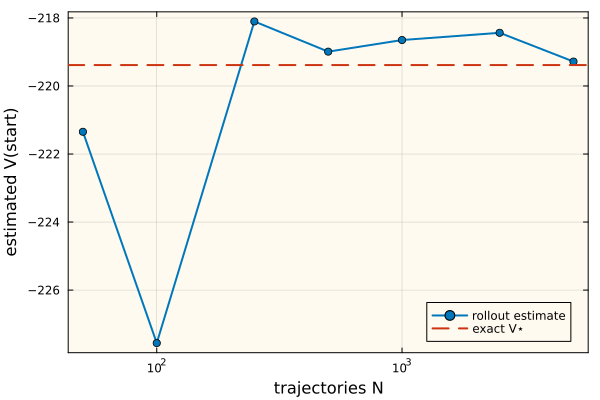

In [5]:
let
    s0 = world.states[(1,1)];
    Ns = [50, 100, 250, 500, 1_000, 2_500, 5_000];
    ests = map(Ns) do n
        rollout_value(mdp, s0; π_fn = s -> π_star[s], H = 200, N = n, rng = Random.MersenneTwister(7));
    end
    plot(Ns, ests, lw = 2, marker = :circle, c = colors[1], label = "rollout estimate", xscale = :log10,
        bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        xlabel = "trajectories N", ylabel = "estimated V(start)");
    hline!([sol.V[s0]], lw = 2, ls = :dash, c = colors[4], label = "exact V⋆")
end

## Rollout Policy Improvement
Now start from a poor base policy — uniformly random actions — and improve it with one step of exact lookahead plus rollout-estimated continuation values. For the start state $s$ and for each action $a$, we compute
$$
\hat Q(s,a) = R(s,a) + \gamma\sum_{s^{\prime}}P(s^{\prime}\mid s,a)\,\hat V^{\pi_{\mathrm{base}}}(s^{\prime}),
$$
summing over the (slip-induced) successor states of $a$ and estimating each $\hat V^{\pi_{\mathrm{base}}}(s^{\prime})$ by rollout of the random base policy. The improved action $\hat\pi(s)=\arg\max_{a}\hat Q(s,a)$ is then compared to the optimal action $\pi^{\star}(s)$.

In [6]:
let
    rng = Random.MersenneTwister(11);
    base = s -> rand(rng, mdp.𝒜);                    # random base policy
    s = world.states[(1,1)];

    # one-step Bellman backup: R(s,a) + γ Σ_s′ P(s′∣s,a) V^base(s′); each continuation value is
    # itself a rollout estimate of the random base policy from s′ -
    scores = map(mdp.𝒜) do a
        successors = [s′ for s′ ∈ mdp.𝒮 if mdp.T[s, s′, a] > 0.0];
        mdp.R[s, a] + mdp.γ*sum(mdp.T[s, s′, a]*rollout_value(mdp, s′; π_fn = base, H = 50, N = 300, rng = rng) for s′ ∈ successors);
    end
    println("rollout-improved action = ", argmax(scores), "   optimal action π⋆(s) = ", π_star[s]);
end

rollout-improved action = 4

   optimal action π⋆(s) = 2


## Summary
This example estimated state values on a $5\times5$ slippery grid world ($\text{slip}=0.2$) by simulating trajectories with `simulate_return`, averaged trajectory returns with `rollout_value` to approximate $V^{\star}(s_{0})$, and used one-step lookahead with rollout-estimated continuation values to improve a random base policy.

> __Key Takeaways:__
>
> * **Rollout estimates value by simulation, not by an exact sweep:** `rollout_value` averages $N$ trajectory returns from `simulate_return` to approximate $V^{\pi}(s_{0})$, without requiring a full sweep over every state and action.
> * **Accuracy improves with the number of trajectories, at rate $1/\sqrt{N}$:** on the slippery grid world, the rollout estimate scatters around the exact $V^{\star}(s_{0})$ from value iteration, with the scatter shrinking as $N$ grows.
> * **One-step rollout lookahead improves a policy without solving the full MDP:** combining an exact Bellman backup with rollout-estimated continuation values turns a random base policy into an improved action choice at a given state.

Rollout trades the exactness of value iteration for an estimate that only needs a simulator and a policy to evaluate, at the cost of Monte Carlo noise that shrinks slowly, at rate $1/\sqrt{N}$, as more trajectories are simulated.
___

### Additional Resources
* Sutton, R. S., & Barto, A. G. (2018). _Reinforcement Learning: An Introduction_ (2nd ed.), Chapter 8. MIT Press.
* Kochenderfer, M. J., Wheeler, T. A., & Wray, K. H. (2022). _Algorithms for Decision Making_. MIT Press.
* Bertsekas, D. P. (2020). _Rollout, Policy Iteration, and Distributed Reinforcement Learning_. Athena Scientific.